In [2]:
# First, let's reload the data and quickly clean it again
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the E-commerce dataset
ecom_path = r"C:\SQL PROJECTS\DATALAB_INTERN\onlineretail.csv"
ecom_df = pd.read_csv(ecom_path, encoding='latin-1')

# Quick cleaning steps
ecom_clean = ecom_df.copy()

# 1. Remove rows with missing CustomerID
ecom_clean = ecom_clean.dropna(subset=['CustomerID'])

# 2. Fill missing Description with 'Unknown'
ecom_clean['Description'] = ecom_clean['Description'].fillna('Unknown')

# 3. Remove negative Quantity and UnitPrice
ecom_clean = ecom_clean[ecom_clean['Quantity'] > 0]
ecom_clean = ecom_clean[ecom_clean['UnitPrice'] > 0]

# 4. Remove invalid StockCodes (starting with 'A')
ecom_clean = ecom_clean[~ecom_clean['StockCode'].astype(str).str.startswith('A', na=False)]

# 5. Remove duplicates
ecom_clean = ecom_clean.drop_duplicates()

# 6. Convert InvoiceDate to datetime
ecom_clean['InvoiceDate'] = pd.to_datetime(ecom_clean['InvoiceDate'])

# 7. Standardize text
ecom_clean['Description'] = ecom_clean['Description'].str.strip().str.upper()
ecom_clean['Country'] = ecom_clean['Country'].str.strip().str.upper()

# 8. Calculate TotalAmount
ecom_clean['TotalAmount'] = ecom_clean['Quantity'] * ecom_clean['UnitPrice']

print("✅ E-commerce dataset reloaded and cleaned successfully!")
print(f"Shape: {ecom_clean.shape}")
print(f"Total Revenue: ${ecom_clean['TotalAmount'].sum():,.2f}")

✅ E-commerce dataset reloaded and cleaned successfully!
Shape: (392692, 9)
Total Revenue: $8,887,208.89


KeyError: 'InvoiceYear'

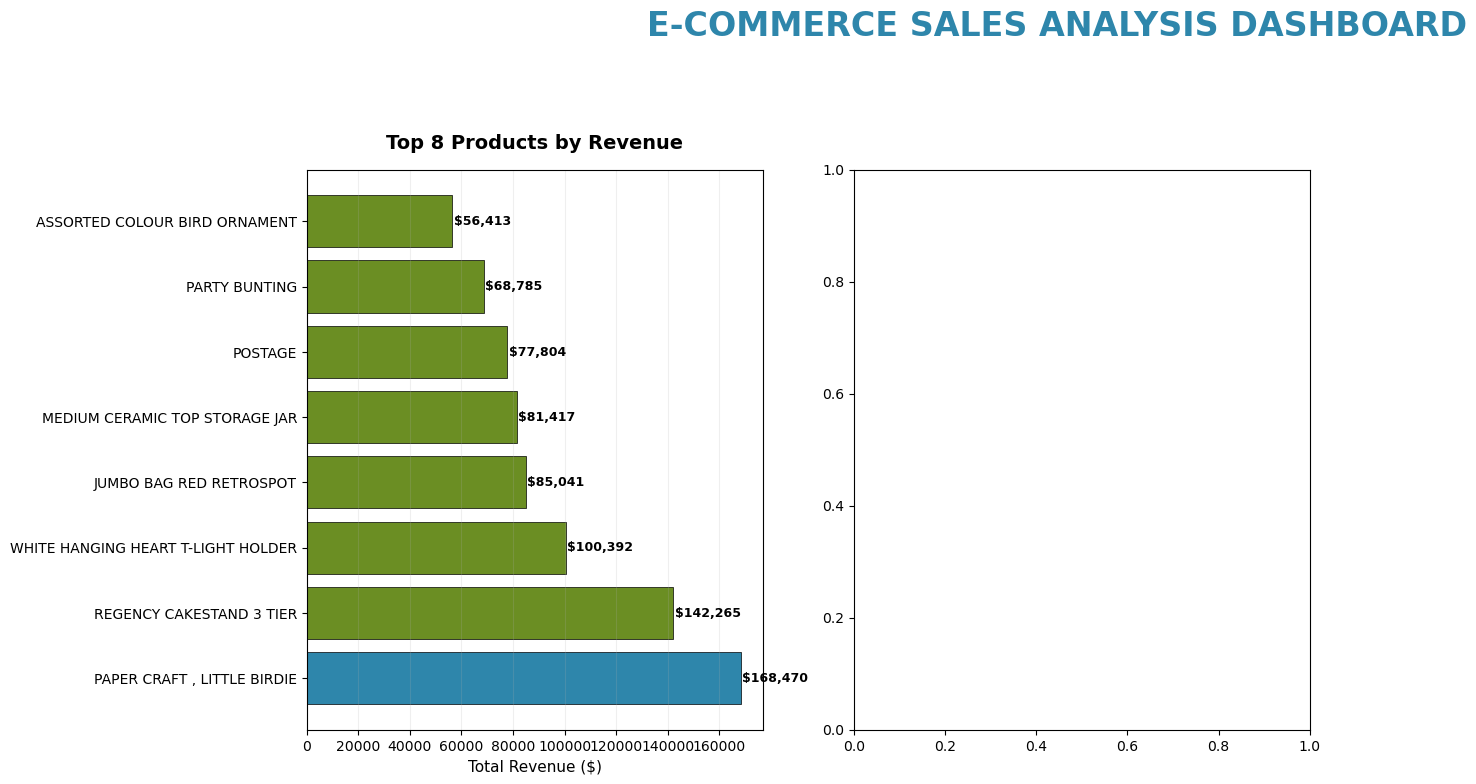

In [3]:
# Create a professional dashboard for E-commerce
fig = plt.figure(figsize=(20, 16))
fig.suptitle('E-COMMERCE SALES ANALYSIS DASHBOARD', fontsize=24, fontweight='bold', y=0.98, color='#2E86AB')

# 1. Top Products by Revenue (Horizontal Bar Chart)
plt.subplot(2, 3, 1)
top_revenue = ecom_clean.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).head(8)
colors_rev = ['#2E86AB'] + ['#6B8E23']*7
bars = plt.barh(top_revenue.index, top_revenue.values, color=colors_rev, edgecolor='black', linewidth=0.5)
plt.title('Top 8 Products by Revenue', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Revenue ($)', fontsize=11)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 500, bar.get_y() + bar.get_height()/2,
             f'${width:,.0f}', ha='left', va='center', fontsize=9, fontweight='bold')
plt.grid(axis='x', alpha=0.2)

# 2. Monthly Sales Trend (Line Chart)
plt.subplot(2, 3, 2)
monthly_sales = ecom_clean.groupby(['InvoiceYear', 'InvoiceMonth'])['TotalAmount'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales['InvoiceYear'].astype(str) + '-' + monthly_sales['InvoiceMonth'].astype(str).str.zfill(2) + '-01')
monthly_sales = monthly_sales.sort_values('Date')
plt.plot(monthly_sales['Date'], monthly_sales['TotalAmount'], marker='o', linewidth=3, markersize=7, color='#2E86AB')
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Total Revenue ($)', fontsize=11)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
# Highlight peak
max_month = monthly_sales.loc[monthly_sales['TotalAmount'].idxmax()]
plt.annotate(f'Peak: ${max_month["TotalAmount"]:,.0f}', 
             xy=(max_month['Date'], max_month['TotalAmount']), 
             xytext=(pd.Timestamp('2011-08-01'), max_month['TotalAmount'] + 100000),
             arrowprops=dict(arrowstyle='->', color='#2E86AB', lw=2),
             fontsize=10, fontweight='bold')

# 3. Top Countries by Revenue (Bar Chart)
plt.subplot(2, 3, 3)
country_revenue = ecom_clean.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(8)
bars = plt.bar(country_revenue.index, country_revenue.values, color='#2E86AB', alpha=0.8, edgecolor='black', linewidth=0.5)
plt.title('Top 8 Countries by Revenue', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Country', fontsize=11)
plt.ylabel('Total Revenue ($)', fontsize=11)
plt.xticks(rotation=45, ha='right')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.grid(axis='y', alpha=0.2)

# 4. Customer Segmentation (Pie Chart)
plt.subplot(2, 3, 4)
customer_spend = ecom_clean.groupby('CustomerID')['TotalAmount'].sum()
high = len(customer_spend[customer_spend > customer_spend.quantile(0.90)])
medium = len(customer_spend[(customer_spend >= customer_spend.quantile(0.50)) & (customer_spend <= customer_spend.quantile(0.90))])
low = len(customer_spend[customer_spend < customer_spend.quantile(0.50)])
segments = [high, medium, low]
labels = [f'High Spenders\nTop 10% ({high})', 
          f'Medium Spenders\n50-90% ({medium})', 
          f'Low Spenders\nBottom 50% ({low})']
colors_seg = ['#2E86AB', '#F18F01', '#8B8B8B']
plt.pie(segments, labels=labels, autopct='%1.1f%%', colors=colors_seg, startangle=90,
        textprops={'fontsize': 10, 'fontweight': 'bold'})
plt.title('Customer Segmentation by Spend', fontsize=14, fontweight='bold', pad=15)

# 5. Order Value Distribution (Histogram)
plt.subplot(2, 3, 5)
order_values = ecom_clean.groupby('InvoiceNo')['TotalAmount'].sum()
order_values = order_values[order_values < order_values.quantile(0.95)]
plt.hist(order_values, bins=40, color='#F18F01', alpha=0.7, edgecolor='black', linewidth=0.5)
plt.title('Order Value Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Order Value ($)', fontsize=11)
plt.ylabel('Number of Orders', fontsize=11)
plt.axvline(order_values.mean(), color='red', linestyle='dashed', 
            linewidth=2, label=f'Mean: ${order_values.mean():.2f}')
plt.axvline(order_values.median(), color='green', linestyle='dashed', 
            linewidth=2, label=f'Median: ${order_values.median():.2f}')
plt.legend(fontsize=9)
plt.grid(alpha=0.2)

# 6. Top Products by Quantity (Horizontal Bar Chart)
plt.subplot(2, 3, 6)
top_quantity = ecom_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(8)
bars = plt.barh(top_quantity.index, top_quantity.values, color='#6B8E23', alpha=0.8, edgecolor='black', linewidth=0.5)
plt.title('Top 8 Products by Quantity Sold', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Quantity', fontsize=11)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 500, bar.get_y() + bar.get_height()/2,
             f'{int(width):,}', ha='left', va='center', fontsize=9, fontweight='bold')
plt.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()

In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the E-commerce dataset
ecom_path = r"C:\SQL PROJECTS\DATALAB_INTERN\onlineretail.csv"
ecom_df = pd.read_csv(ecom_path, encoding='latin-1')

# Quick cleaning steps
ecom_clean = ecom_df.copy()

# 1. Remove rows with missing CustomerID
ecom_clean = ecom_clean.dropna(subset=['CustomerID'])

# 2. Fill missing Description with 'Unknown'
ecom_clean['Description'] = ecom_clean['Description'].fillna('Unknown')

# 3. Remove negative Quantity and UnitPrice
ecom_clean = ecom_clean[ecom_clean['Quantity'] > 0]
ecom_clean = ecom_clean[ecom_clean['UnitPrice'] > 0]

# 4. Remove invalid StockCodes (starting with 'A')
ecom_clean = ecom_clean[~ecom_clean['StockCode'].astype(str).str.startswith('A', na=False)]

# 5. Remove duplicates
ecom_clean = ecom_clean.drop_duplicates()

# 6. Convert InvoiceDate to datetime
ecom_clean['InvoiceDate'] = pd.to_datetime(ecom_clean['InvoiceDate'])

# 7. Create date components (THIS IS THE FIX)
ecom_clean['InvoiceYear'] = ecom_clean['InvoiceDate'].dt.year
ecom_clean['InvoiceMonth'] = ecom_clean['InvoiceDate'].dt.month
ecom_clean['InvoiceDay'] = ecom_clean['InvoiceDate'].dt.day
ecom_clean['InvoiceHour'] = ecom_clean['InvoiceDate'].dt.hour

# 8. Standardize text
ecom_clean['Description'] = ecom_clean['Description'].str.strip().str.upper()
ecom_clean['Country'] = ecom_clean['Country'].str.strip().str.upper()

# 9. Calculate TotalAmount
ecom_clean['TotalAmount'] = ecom_clean['Quantity'] * ecom_clean['UnitPrice']

print("✅ E-commerce dataset reloaded and cleaned successfully!")
print(f"Shape: {ecom_clean.shape}")
print(f"Date range: {ecom_clean['InvoiceDate'].min()} to {ecom_clean['InvoiceDate'].max()}")
print(f"Total Revenue: ${ecom_clean['TotalAmount'].sum():,.2f}")
print(f"\nFirst 5 rows with date components:")
print(ecom_clean[['InvoiceDate', 'InvoiceYear', 'InvoiceMonth', 'InvoiceDay', 'InvoiceHour', 'TotalAmount']].head())

✅ E-commerce dataset reloaded and cleaned successfully!
Shape: (392692, 13)
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Total Revenue: $8,887,208.89

First 5 rows with date components:
          InvoiceDate  InvoiceYear  InvoiceMonth  InvoiceDay  InvoiceHour  \
0 2010-12-01 08:26:00         2010            12           1            8   
1 2010-12-01 08:26:00         2010            12           1            8   
2 2010-12-01 08:26:00         2010            12           1            8   
3 2010-12-01 08:26:00         2010            12           1            8   
4 2010-12-01 08:26:00         2010            12           1            8   

   TotalAmount  
0        15.30  
1        20.34  
2        22.00  
3        20.34  
4        20.34  


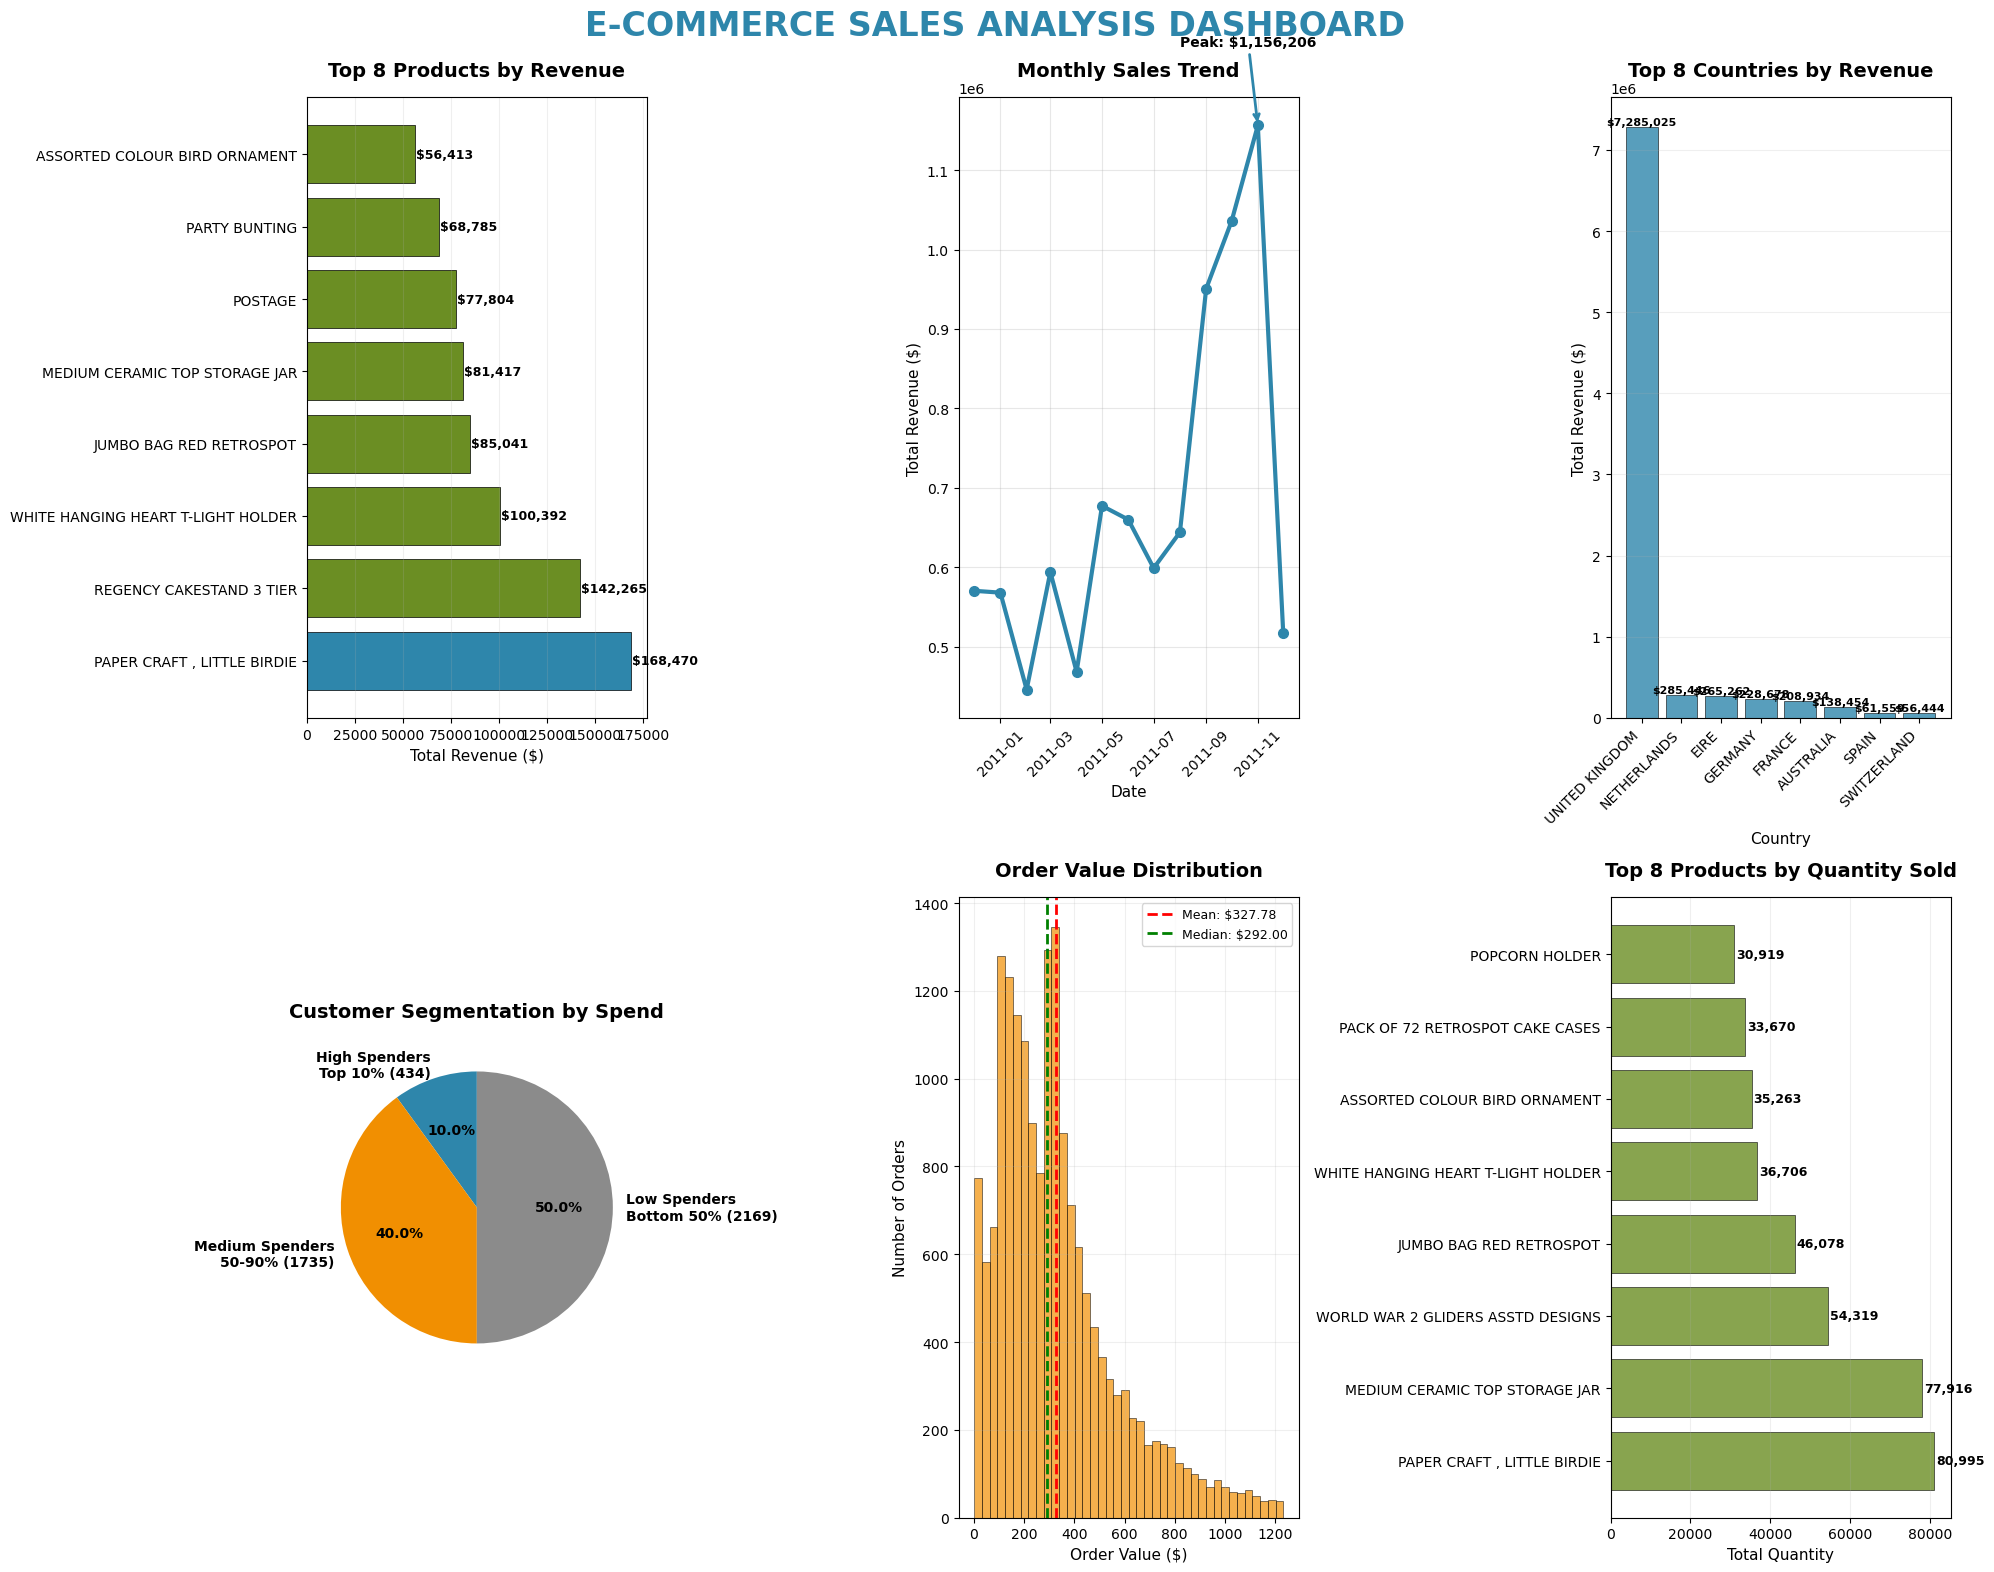

In [6]:
# Create a professional dashboard for E-commerce
fig = plt.figure(figsize=(20, 16))
fig.suptitle('E-COMMERCE SALES ANALYSIS DASHBOARD', fontsize=24, fontweight='bold', y=0.98, color='#2E86AB')

# 1. Top Products by Revenue (Horizontal Bar Chart)
plt.subplot(2, 3, 1)
top_revenue = ecom_clean.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).head(8)
colors_rev = ['#2E86AB'] + ['#6B8E23']*7
bars = plt.barh(top_revenue.index, top_revenue.values, color=colors_rev, edgecolor='black', linewidth=0.5)
plt.title('Top 8 Products by Revenue', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Revenue ($)', fontsize=11)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 500, bar.get_y() + bar.get_height()/2,
             f'${width:,.0f}', ha='left', va='center', fontsize=9, fontweight='bold')
plt.grid(axis='x', alpha=0.2)

# 2. Monthly Sales Trend (Line Chart)
plt.subplot(2, 3, 2)
monthly_sales = ecom_clean.groupby(['InvoiceYear', 'InvoiceMonth'])['TotalAmount'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales['InvoiceYear'].astype(str) + '-' + monthly_sales['InvoiceMonth'].astype(str).str.zfill(2) + '-01')
monthly_sales = monthly_sales.sort_values('Date')
plt.plot(monthly_sales['Date'], monthly_sales['TotalAmount'], marker='o', linewidth=3, markersize=7, color='#2E86AB')
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Total Revenue ($)', fontsize=11)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
# Highlight peak
max_month = monthly_sales.loc[monthly_sales['TotalAmount'].idxmax()]
plt.annotate(f'Peak: ${max_month["TotalAmount"]:,.0f}', 
             xy=(max_month['Date'], max_month['TotalAmount']), 
             xytext=(pd.Timestamp('2011-08-01'), max_month['TotalAmount'] + 100000),
             arrowprops=dict(arrowstyle='->', color='#2E86AB', lw=2),
             fontsize=10, fontweight='bold')

# 3. Top Countries by Revenue (Bar Chart)
plt.subplot(2, 3, 3)
country_revenue = ecom_clean.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(8)
bars = plt.bar(country_revenue.index, country_revenue.values, color='#2E86AB', alpha=0.8, edgecolor='black', linewidth=0.5)
plt.title('Top 8 Countries by Revenue', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Country', fontsize=11)
plt.ylabel('Total Revenue ($)', fontsize=11)
plt.xticks(rotation=45, ha='right')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.grid(axis='y', alpha=0.2)

# 4. Customer Segmentation (Pie Chart)
plt.subplot(2, 3, 4)
customer_spend = ecom_clean.groupby('CustomerID')['TotalAmount'].sum()
high = len(customer_spend[customer_spend > customer_spend.quantile(0.90)])
medium = len(customer_spend[(customer_spend >= customer_spend.quantile(0.50)) & (customer_spend <= customer_spend.quantile(0.90))])
low = len(customer_spend[customer_spend < customer_spend.quantile(0.50)])
segments = [high, medium, low]
labels = [f'High Spenders\nTop 10% ({high})', 
          f'Medium Spenders\n50-90% ({medium})', 
          f'Low Spenders\nBottom 50% ({low})']
colors_seg = ['#2E86AB', '#F18F01', '#8B8B8B']
plt.pie(segments, labels=labels, autopct='%1.1f%%', colors=colors_seg, startangle=90,
        textprops={'fontsize': 10, 'fontweight': 'bold'})
plt.title('Customer Segmentation by Spend', fontsize=14, fontweight='bold', pad=15)

# 5. Order Value Distribution (Histogram)
plt.subplot(2, 3, 5)
order_values = ecom_clean.groupby('InvoiceNo')['TotalAmount'].sum()
order_values = order_values[order_values < order_values.quantile(0.95)]
plt.hist(order_values, bins=40, color='#F18F01', alpha=0.7, edgecolor='black', linewidth=0.5)
plt.title('Order Value Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Order Value ($)', fontsize=11)
plt.ylabel('Number of Orders', fontsize=11)
plt.axvline(order_values.mean(), color='red', linestyle='dashed', 
            linewidth=2, label=f'Mean: ${order_values.mean():.2f}')
plt.axvline(order_values.median(), color='green', linestyle='dashed', 
            linewidth=2, label=f'Median: ${order_values.median():.2f}')
plt.legend(fontsize=9)
plt.grid(alpha=0.2)

# 6. Top Products by Quantity (Horizontal Bar Chart)
plt.subplot(2, 3, 6)
top_quantity = ecom_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(8)
bars = plt.barh(top_quantity.index, top_quantity.values, color='#6B8E23', alpha=0.8, edgecolor='black', linewidth=0.5)
plt.title('Top 8 Products by Quantity Sold', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Quantity', fontsize=11)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 500, bar.get_y() + bar.get_height()/2,
             f'{int(width):,}', ha='left', va='center', fontsize=9, fontweight='bold')
plt.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()